# Лабораторная работа №5
## Задание
Выделить на изображении что-нибудь

## Решение
### Исходное изображение


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


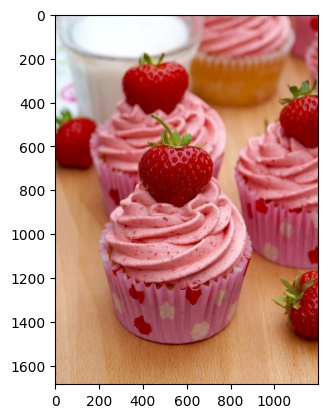

In [ ]:
import cv2
from matplotlib.colors import hsv_to_rgb
from matplotlib import pyplot as plt
from google.colab import files
from google.colab.patches import cv2_imshow
import numpy as np
from google.colab import drive
from matplotlib import colors

image_path = '/content/drive/MyDrive/Colab Notebooks/ЦОИ отчеты/lab5.jpg'
img = cv2.imread(image_path)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)

In [ ]:
image_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

Для удобства просмотрим изображение по каналам на графике

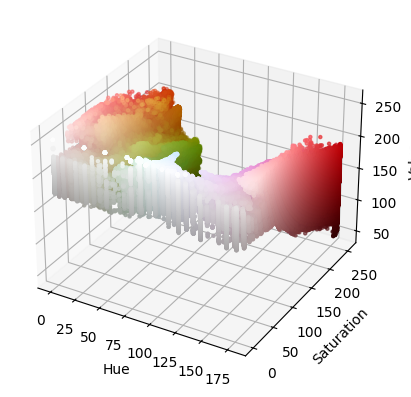

In [ ]:
# @title
h, s, v = cv2.split(image_hsv)
fig = plt.figure()
axis = fig.add_subplot(1, 1, 1, projection="3d")

axis.scatter(h.flatten(), s.flatten(), v.flatten(), facecolors=pixel_colors, marker=".")
axis.set_xlabel("Hue")
axis.set_ylabel("Saturation")
axis.set_zlabel("Value")
plt.show()

Пробуем подобрать пороги для ягод

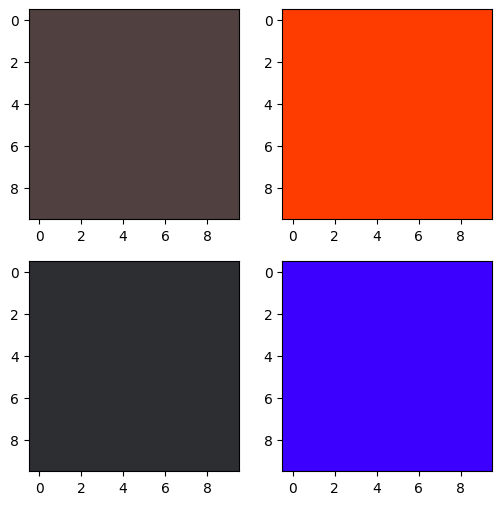

In [ ]:
berry_lower1 = np.array([0, 50, 80])
berry_upper1 = np.array([10, 255, 255])
berry_lower2 = np.array([150, 30, 50])
berry_upper2 = np.array([180, 255, 255])
lo1_square = np.full((10, 10, 3), berry_lower1, dtype=np.uint8) / 255.0
up1_square = np.full((10, 10, 3), berry_upper1, dtype=np.uint8) / 255.0
lo2_square = np.full((10, 10, 3), berry_lower2, dtype=np.uint8) / 255.0
up2_square = np.full((10, 10, 3), berry_upper2, dtype=np.uint8) / 255.0

fig, axes = plt.subplots(2, 2, figsize=(6, 6))

axes[0, 0].imshow(hsv_to_rgb(lo1_square))
axes[0, 1].imshow(hsv_to_rgb(up1_square))
axes[1, 0].imshow(hsv_to_rgb(lo2_square))
axes[1, 1].imshow(hsv_to_rgb(up2_square))
plt.show()

Выделить отдельно ягоды проблематично, так как красный горошек на обертке в точности совпадает с цветом ягоды. В честь этого будем выделять кекс целиком!

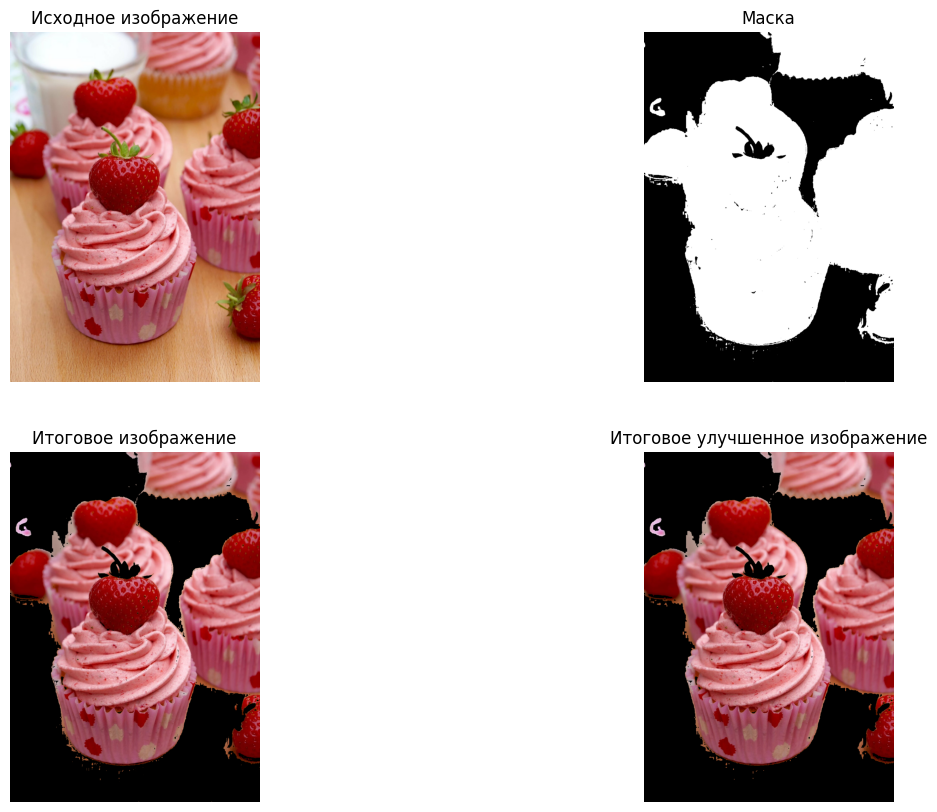

In [ ]:
mask1 = cv2.inRange(image_hsv, berry_lower1, berry_upper1)
mask2 = cv2.inRange(image_hsv, berry_lower2, berry_upper2)
final_mask = cv2.bitwise_or(mask1, mask2)

kernel = np.ones((3, 3), np.uint8)
mask_cleaned = cv2.morphologyEx(final_mask, cv2.MORPH_CLOSE, kernel)
mask_cleaned = cv2.morphologyEx(mask_cleaned, cv2.MORPH_OPEN, kernel)

result = cv2.bitwise_and(img_rgb, img_rgb, mask=final_mask)
result_clean = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_cleaned)

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Исходное изображение")

plt.subplot(2, 2, 2)
plt.imshow(final_mask, cmap="gray")
plt.axis("off")
plt.title("Маска")

plt.subplot(2, 2, 3)
plt.imshow(result)
plt.axis("off")
plt.title("Итоговое изображение")

plt.subplot(2, 2, 4)
plt.imshow(result_clean)
plt.axis("off")
plt.title("Итоговое улучшенное изображение")

plt.show()

Если игарть по-честному, и прям один цвет выделять, то можно выделить черенки от ягод:

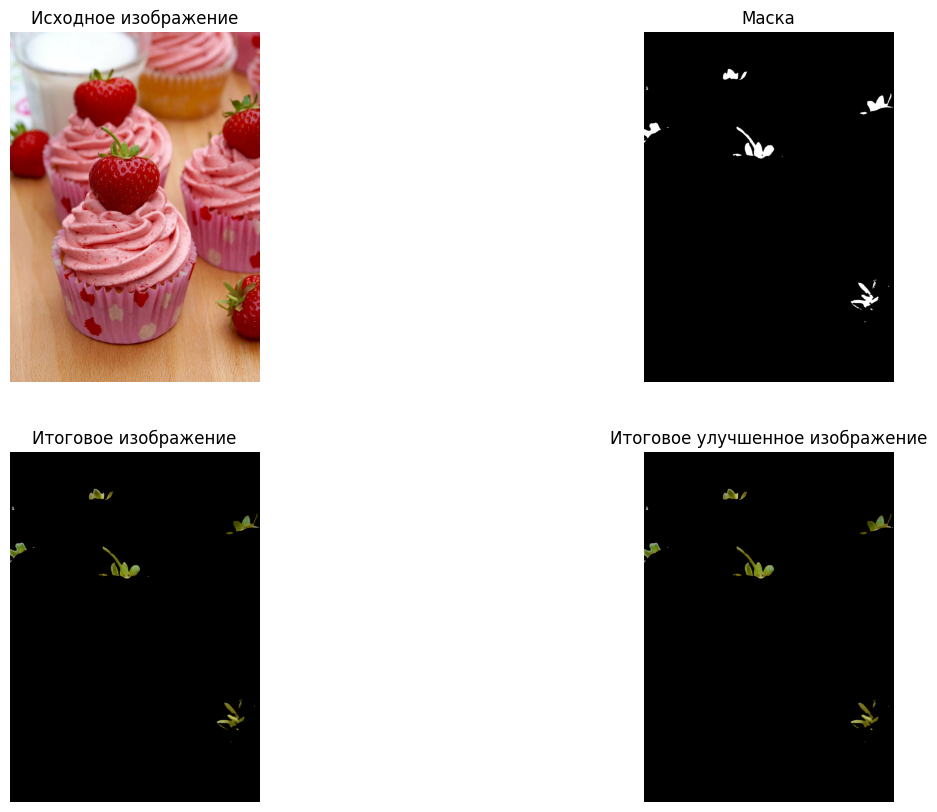

In [ ]:
# @title
leaf_lower = np.array([25, 30, 30])
leaf_upper = np.array([95, 255, 255])

mask_leaf = cv2.inRange(image_hsv, leaf_lower, leaf_upper)

kernel = np.ones((3, 3), np.uint8)
mask_cleaned = cv2.morphologyEx(mask_leaf, cv2.MORPH_CLOSE, kernel)
mask_cleaned = cv2.morphologyEx(mask_cleaned, cv2.MORPH_OPEN, kernel)

result = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_leaf)
result_clean = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_cleaned)

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Исходное изображение")

plt.subplot(2, 2, 2)
plt.imshow(mask_leaf, cmap="gray")
plt.axis("off")
plt.title("Маска")

plt.subplot(2, 2, 3)
plt.imshow(result)
plt.axis("off")
plt.title("Итоговое изображение")

plt.subplot(2, 2, 4)
plt.imshow(result_clean)
plt.axis("off")
plt.title("Итоговое улучшенное изображение")

plt.show()